$$
X = \begin{bmatrix}x_0 & x_1 & \cdots & x_{T-2}\end{bmatrix},
\qquad
Y = \begin{bmatrix}x_1 & x_2 & \cdots & x_{T-1}\end{bmatrix}
$$

$$
X = U\Sigma V^*
$$

$$
U_r = U[:,1\!:\!r],
\qquad
\Sigma_r = \Sigma[1\!:\!r,1\!:\!r],
\qquad
V_r = V[:,1\!:\!r]
$$

$$
\widetilde A = U_r^* Y V_r \Sigma_r^{-1}
$$

$$
\widetilde A W = W\Lambda
$$

$$
\Phi = Y V_r \Sigma_r^{-1} W
$$

$$
B = \Phi^{\dagger} X
$$

$$
\widehat X = \Phi \Lambda B
$$

In [1]:
from pathlib import Path
import sys

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from rich.console import Console
from rich.table import Table

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from tdmd import dmd

plt.style.use("ggplot")

In [2]:
def make_plasma(nx=100, ny=100, nt=100):
    x = jnp.linspace(-1.0, 1.0, nx)
    y = jnp.linspace(-1.0, 1.0, ny)
    t = jnp.linspace(0.0, 4.0 * jnp.pi, nt)
    X, Y, T = jnp.meshgrid(x, y, t, indexing="ij")

    Xf = 5.0 * X - 5.0
    Yf = 5.0 * Y - 5.0
    R = jnp.sqrt(Xf**2 + Yf**2)
    Theta = jnp.arctan2(Yf, Xf + 1.0e-6)

    Z = (
        7.0 * jnp.sin(1.7 * Xf + 0.9 * T)
        + 6.0 * jnp.cos(1.3 * Yf - 1.2 * T)
        + 5.0 * jnp.sin(0.9 * (Xf + Yf) + 0.7 * T)
        + 4.0 * jnp.cos(2.2 * R - 1.8 * T)
        + 3.0 * jnp.sin(3.0 * Theta + 0.6 * R - 1.1 * T)
        + 2.5 * jnp.cos(1.8 * (Xf - Yf) + 0.3 * R + 0.8 * T)
    )
    return Z, t


def split_shifted_matrix(sequence):
    X = sequence[:, :, :-1].reshape(sequence.shape[0] * sequence.shape[1], -1)
    Y = sequence[:, :, 1:].reshape(sequence.shape[0] * sequence.shape[1], -1)
    return X, Y


def relative_error(target, approx):
    return float(jnp.linalg.norm(target - approx) / jnp.linalg.norm(target))


def draw_frame(ax, frame, title, cmap="magma"):
    image = ax.imshow(np.asarray(jnp.real(frame)), origin="lower", cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return image

In [5]:
Z, t = make_plasma(nx=96, ny=96, nt=128)
X, Y = split_shifted_matrix(Z[:, :, :96])

rank = 20
energy_threshold = 0.995
svd_threshold = 1.0e-8

pred_idx = 127

modes, eigenvalues = dmd(
    X,
    Y,
    rank=rank,
    energy_threshold=energy_threshold,
    svd_threshold=svd_threshold,
)

init = jnp.linalg.lstsq(modes, X[:, 0], rcond=None)[0]
y_hat = modes @ jnp.diag(eigenvalues**pred_idx) @ init
y_hat = y_hat.reshape(Z.shape[0], Z.shape[1])
y_true = Z[:, :, pred_idx]

error = relative_error(y_true, y_hat)

table = Table(title="DMD Results")

table.add_column("Name", no_wrap=True)
table.add_column("Value")

table.add_row("sequence shape", f"{tuple(Z.shape)}")
table.add_row("modes shape", f"{tuple(modes.shape)}")
table.add_row("eigenvalues shape", f"{tuple(eigenvalues.shape)}")
table.add_row("relative error", f"{error:.4e}")

console = Console()
console.print(table)


             DMD Results             
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Name              ┃ Value         ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence shape    │ (96, 96, 128) │
│ modes shape       │ (9216, 6)     │
│ eigenvalues shape │ (6,)          │
│ relative error    │ 6.0093e-01    │
└───────────────────┴───────────────┘

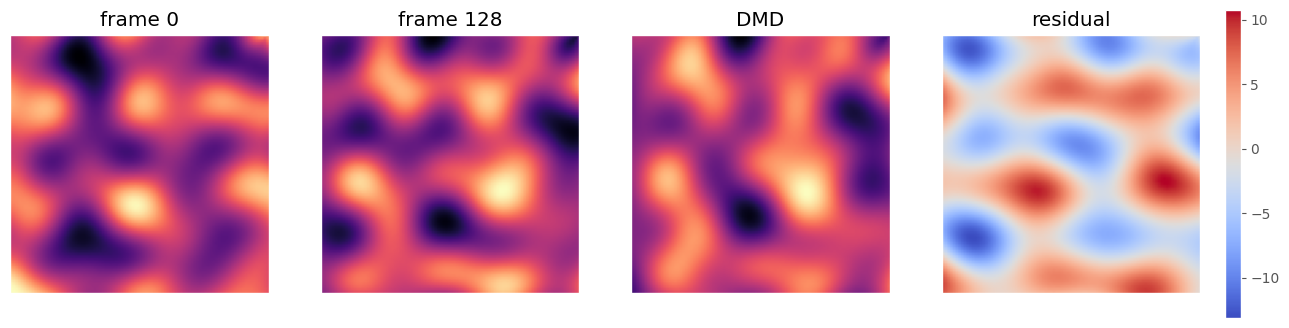

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
img0 = draw_frame(axes[0], Z[:, :, 0], "frame 0")
img1 = draw_frame(axes[1], y_true, f"frame {pred_idx + 1}")
img2 = draw_frame(axes[2], y_hat, "DMD")
img3 = draw_frame(axes[3], y_true - y_hat, "residual", cmap="coolwarm")
fig.colorbar(img3, ax=axes, fraction=0.02, pad=0.02)

plt.show();